In [1]:
# Hierarchical clustering: Dendogram + cluster visualization
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import linkage, dendrogram

# Load the real dataset 
data= load_wine()
X= data.data

# Standardize features (important for distance_based methods)
X_scaled= StandardScaler().fit_transform(X)

X_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

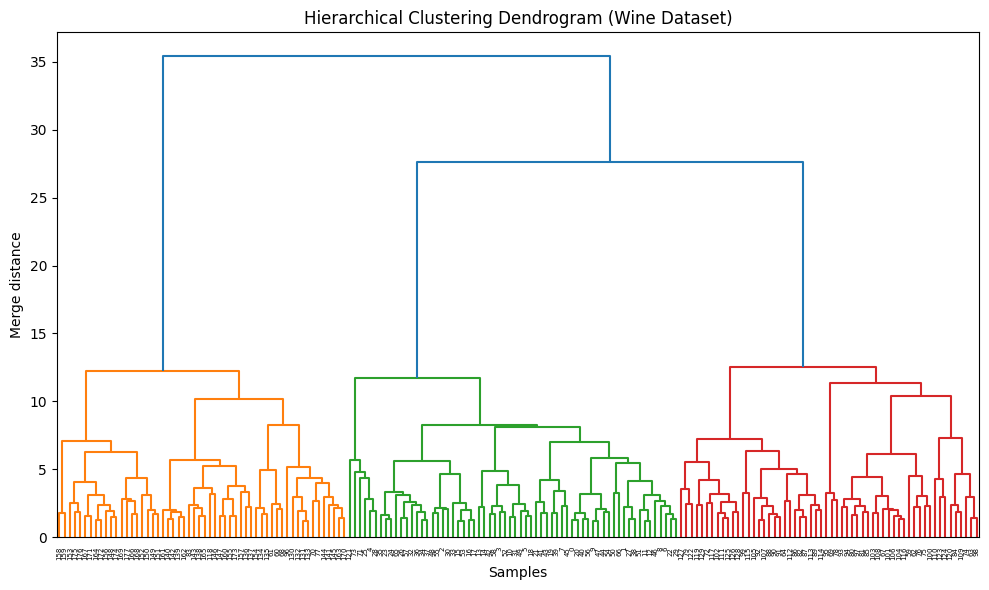

In [2]:
# Compute the linkage matrix for dendrogram
Z = linkage(X_scaled, method='ward')

# Plot Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)

plt.title('Hierarchical Clustering Dendrogram (Wine Dataset)')
plt.xlabel('Samples')
plt.ylabel('Merge distance')
plt.tight_layout()

plt.show()

In [5]:
# Fit the Hierarchical clustering model
n_clusters = 3
hc= AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='ward'
)

labels= hc.fit_predict(X_scaled)
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 0, 2,
       2, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

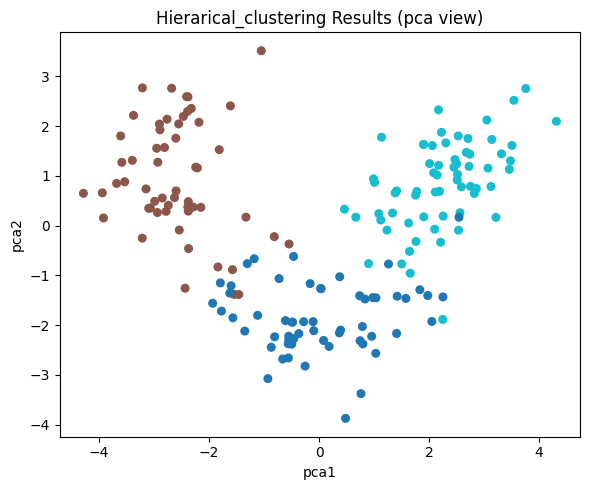

In [4]:
# reduce to 2D for viz
pca= PCA(n_components=2, random_state=42)
X_2d= pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=30)
plt.title("Hierarical_clustering Results (pca view)")
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.tight_layout()
plt.show()

In [6]:
print("Cluster count:", np.bincount(labels))

Cluster count: [58 56 64]
